<a href="https://colab.research.google.com/github/MaxHolikov/DataScience/blob/main/hw4/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лог-файл не существует.
    Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              286.0            High      No   
2  46.0    Male           126.0              216.0             Low      No   
3  32.0  Female           122.0              293.0            High     Yes   
4  60.0    Male           166.0              242.0             Low     Yes   

  Family Heart Disease Diabetes        BMI High Blood Pressure  ...  \
0                  Yes       No  24.991591                 Yes  ...   
1                  Yes      Yes  25.221799                  No  ...   
2                   No       No  29.855447                  No  ...   
3                  Yes       No  24.130477                 Yes  ...   
4                  Yes      Yes  20.486289                 Yes  ...   

  High LDL Cholesterol Alcohol Consumption Stress Level Sleep Hours  \
0        

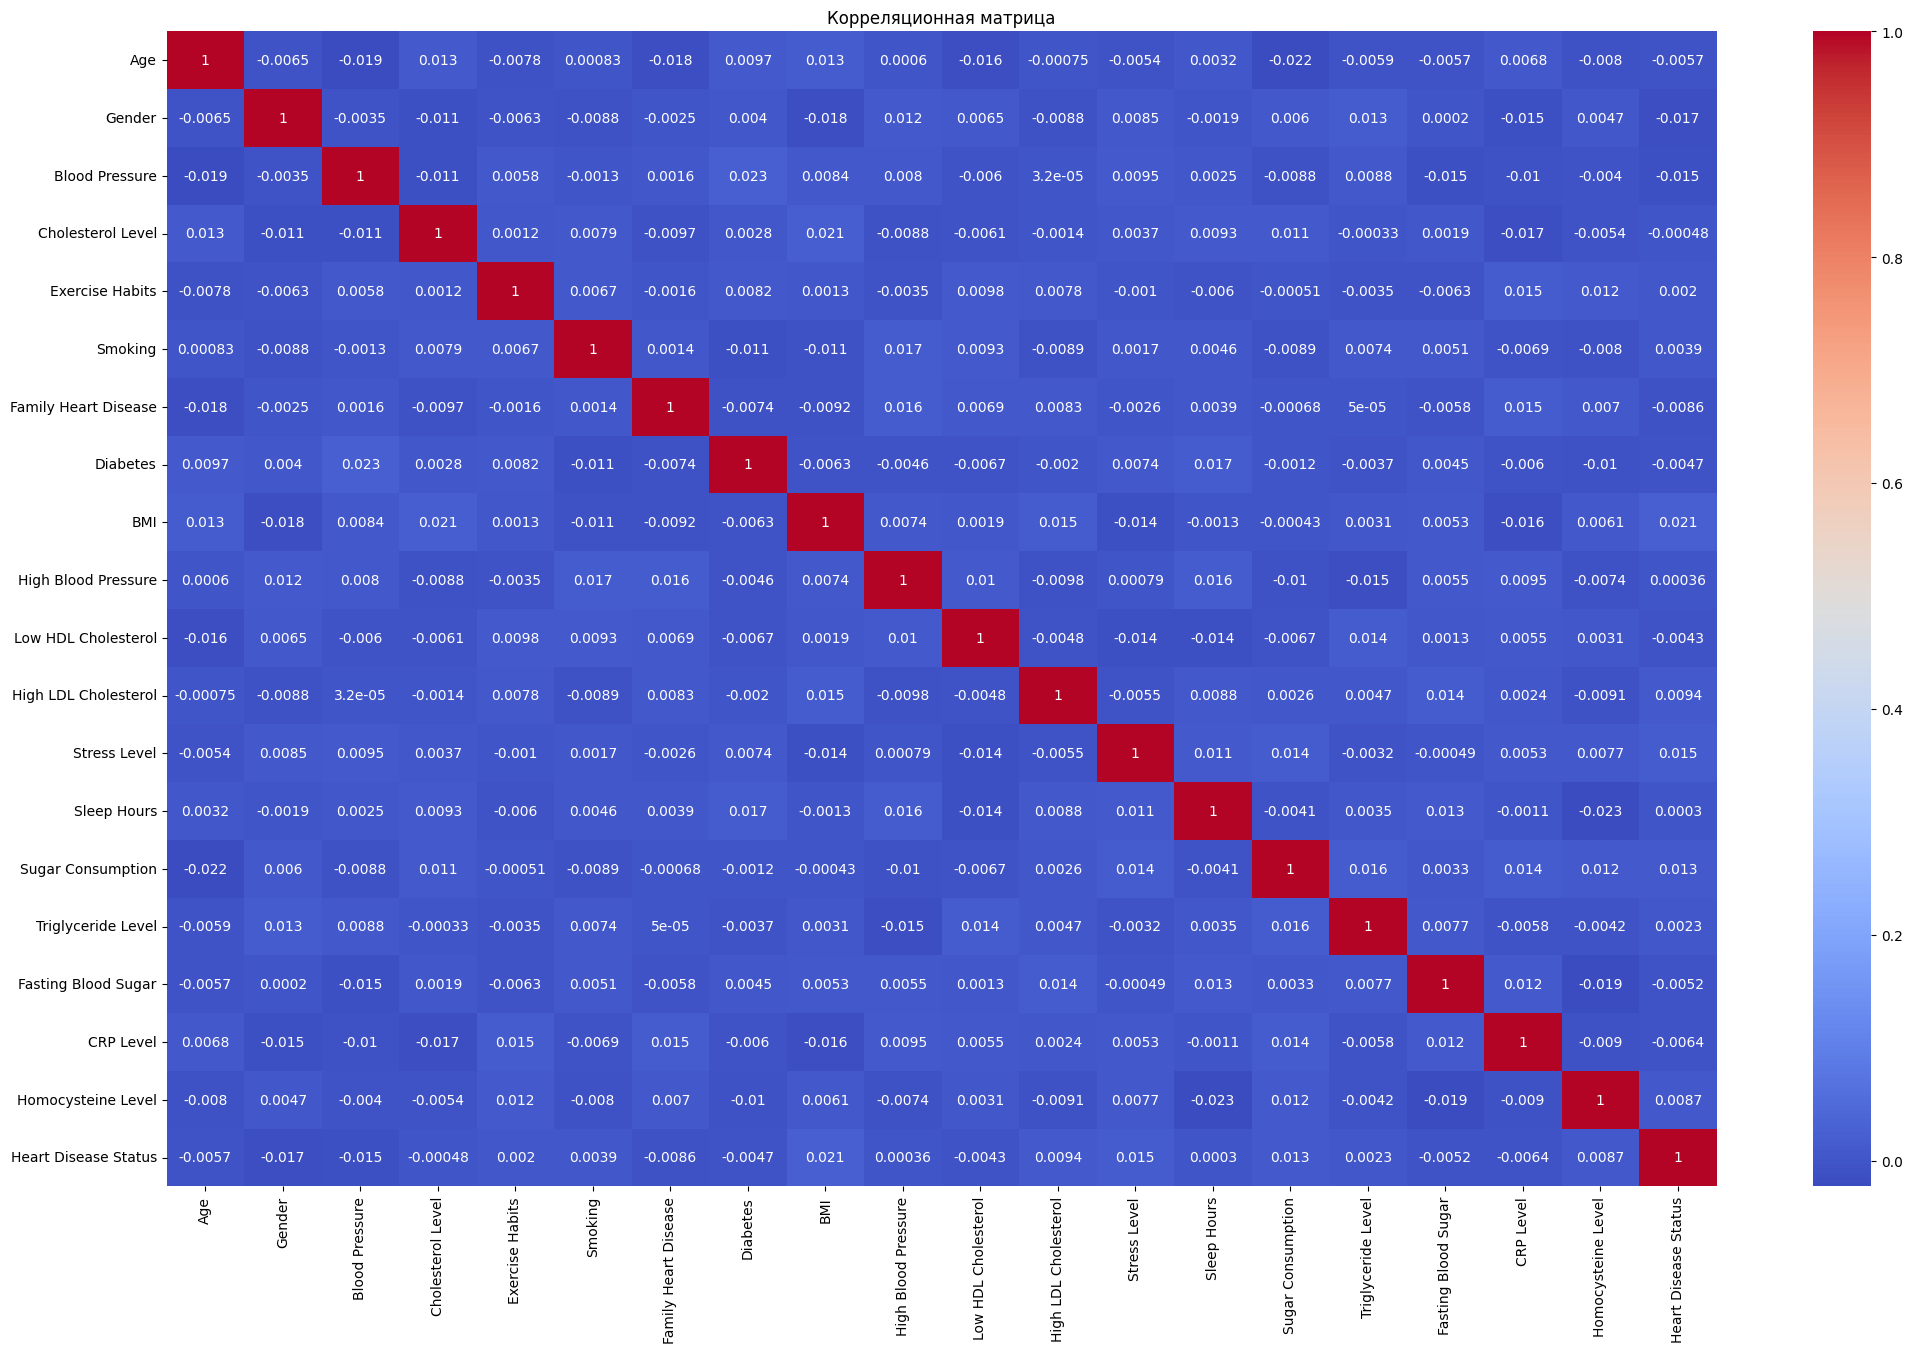

Содержимое лог-файла:
2026-03-02 19:58:49 - INFO - File: .csv загружен
2026-03-02 19:58:49 - INFO - Количество пропущенных значений: 468
2026-03-02 19:58:49 - INFO - Удалено 468 строк с пропущенными значениями
2026-03-02 19:58:49 - INFO - Количество пропущенных значений после обработки: 0
2026-03-02 19:58:49 - INFO -  Данные преобразованы к цифровым значениям
2026-03-02 19:58:49 - INFO -  Данные преобразованы к цифровым значениям
2026-03-02 19:58:49 - INFO -  Данные преобразованы к цифровым значениям
2026-03-02 19:58:49 - INFO -  Данные преобразованы к цифровым значениям
2026-03-02 19:58:49 - INFO -  Данные преобразованы к цифровым значениям
2026-03-02 19:58:49 - INFO -  Данные преобразованы к цифровым значениям
2026-03-02 19:58:49 - INFO -  Данные преобразованы к цифровым значениям
2026-03-02 19:58:49 - INFO -  Данные преобразованы к цифровым значениям
2026-03-02 19:58:49 - INFO -  Данные преобразованы к цифровым значениям
2026-03-02 19:58:49 - INFO -  Данные преобразованы к цифровым 

In [1]:
#pip install kaggle

import get_dataset as gd
import logger as lg
from data_processing import DataProcessing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Определяем пути источника и назначения , добавить kaggle.json
lg.clear_log_file()

'''gd.load_dataset_pdf()

!kaggle datasets download -d oktayrdeki/heart-disease

#распаковка .zip - файла
gd.unpacking_zip('heart-disease.zip', 'heart-disease')

gd.view_file('heart-disease')

file_path='heart-disease/heart_disease.csv'
'''
file_path='heart_disease.csv'
gd.read_file(file_path)


try:
    df = pd.read_csv(file_path)
    lg.log_event("INFO", "File: .csv загружен" )
except FileNotFoundError:
    lg.log_event("ERROR", "Cannot file: .csv! Load file: .csv!" )

processing = DataProcessing(df)

missing_values = processing.count_missing()
print('=================')
print(f"Колличество пропущенных значений в датасете: {missing_values}\n")
processing.missing_report()
print('=================')
df= df.drop(['Alcohol Consumption'], axis=1, inplace=True)  # точность модели увеличивается с 0.7685 до 0.7881
#df= df.drop(['Alcohol Consumption','Homocysteine Level','CRP Level','Fasting Blood Sugar'], axis=1, inplace=True) # точность модели 0.7942
#df= df.drop(['Alcohol Consumption','Homocysteine Level','Fasting Blood Sugar'], axis=1, inplace=True) # точность модели 0.81 - ПЕРЕОБУЧЕНИЕ
#df= df.drop(['Alcohol Consumption','CRP Level','Fasting Blood Sugar','Triglyceride Level','Family Heart Disease','Diabetes','Low HDL Cholesterol'], axis=1, inplace=True)
missing_values = processing.count_missing()
print(f"Колличество пропущенных значений в датасете: {missing_values}\n")

if missing_values>0:
  print(f"Количество пропущенных значений: {missing_values} \n")
  lg.log_event("INFO", f"Количество пропущенных значений: {missing_values}" )
  processing.missing_report()

  #processing.fill_missing('mean')  #заполнение пустых ячеек

  df_clean = processing.drop_missing_rows(inplace=True)   #удаление пустых ячеек
  processing.missing_report()

  missing_values = processing.count_missing()
  print(f"Колличество пропущенных значений в датасете: {missing_values}\n")
  print('=================')
  #processing.fill_missing_new(numeric_strategy='median', categorical_strategy='mode')

  lg.log_event("INFO", f"Количество пропущенных значений после обработки: {processing.count_missing()}" )
  #processing.data.to_csv('cleaned_data.csv', index=False)   # сохранение отредактированных данных в файл
  #lg.log_event("INFO", "Оттредактированные данные сохранены в файл 'cleaned_data.csv'.")

else:
  print(f"Количество пропущенных значений: {missing_values} \n")

# преобразования категориальных колонок в числовые
processing.convert_to_numeric()
lg.log_event("INFO", f"Количество пропущенных значений после обработки: {processing.count_missing()}" )
processing.data.to_csv('num_data.csv', index=False)   # сохранение отредактированных данных в файл
lg.log_event("INFO", "Оттредактированные данные сохранены в файл 'num_data.csv'.")

df = pd.read_csv('num_data.csv')

numeric_data = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(25, 15))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

if __name__ == "__main__":
    lg.read_log_file()



In [2]:
import get_dataset as gd
import logger as lg
from data_processing import DataProcessing
from classification import Classification
import pandas as pd

#file_path='heart-disease/heart_disease.csv'

lg.clear_log_file()

file_path='num_data.csv'
try:
  df = pd.read_csv(file_path)
  lg.log_event("INFO", "File: .csv загружен" )
except FileNotFoundError:
  lg.log_event("ERROR", "Cannot file: .csv! Load file: .csv!" )

cl=Classification(df)

rez_grad_boost=cl.grad_boosting()

cl.ada_boosting()

cl.extra_trees()

cl.k_neighbors()

cl.dec_tree()

if __name__ == "__main__":
  lg.read_log_file()

Лог-файл успешно очищен.
     Gradient Boosting:
    Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      1887
           1       0.15      0.00      0.01       496

    accuracy                           0.79      2383
   macro avg       0.47      0.50      0.44      2383
weighted avg       0.66      0.79      0.70      2383

     ADABoosting:
    Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      1887
           1       0.00      0.00      0.00       496

    accuracy                           0.79      2383
   macro avg       0.40      0.50      0.44      2383
weighted avg       0.63      0.79      0.70      2383

     ExtraTreesClassifier:
    Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      1887
           1       0.00      0.00      0.00       496

    accuracy                   